In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load the dataset
vvix = pd.read_csv("vvix.csv", skiprows=2)
vvix.head()

,Date,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,2007-01-03,87.629997,87.629997,87.629997,87.629997,0
1,2007-01-04,88.190002,88.190002,88.190002,88.190002,0
2,2007-01-05,90.169998,90.169998,90.169998,90.169998,0
3,2007-01-08,92.040001,92.040001,92.040001,92.040001,0
4,2007-01-09,92.760002,92.760002,92.760002,92.760002,0


In [ ]:
# Rename columns
vvix.columns = ['Date', 'VVIX_Close', 'VVIX_High', 'VVIX_Low', 'VVIX_Open', 'VVIX_Volume']
vvix.head()

,Date,VVIX_Close,VVIX_High,VVIX_Low,VVIX_Open,VVIX_Volume
0,2007-01-03,87.629997,87.629997,87.629997,87.629997,0
1,2007-01-04,88.190002,88.190002,88.190002,88.190002,0
2,2007-01-05,90.169998,90.169998,90.169998,90.169998,0
3,2007-01-08,92.040001,92.040001,92.040001,92.040001,0
4,2007-01-09,92.760002,92.760002,92.760002,92.760002,0


In [ ]:
# Remove all columns except 'Date' and 'VVIX_Close'
vvix = vvix[['Date', 'VVIX_Close']]
vvix.head()

,Date,VVIX_Close
0,2007-01-03,87.629997
1,2007-01-04,88.190002
2,2007-01-05,90.169998
3,2007-01-08,92.040001
4,2007-01-09,92.760002


In [ ]:
# Convert 'Date' column to datetime
vvix['Date'] = pd.to_datetime(vvix['Date'])
vvix.head()
vvix.tail()

,Date,VVIX_Close
4705,2025-09-29,96.739998
4706,2025-09-30,95.889999
4707,2025-10-01,93.220001
4708,2025-10-02,94.099998
4709,2025-10-03,94.790001


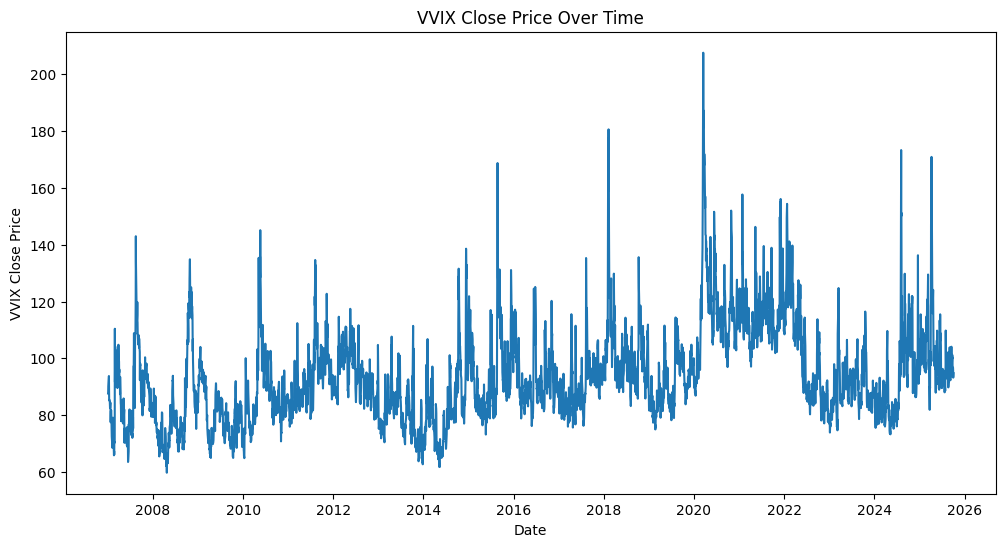

In [ ]:
# Visualize data to inspect
plt.figure(figsize=(12, 6))
plt.plot(vvix['Date'], vvix['VVIX_Close'])
plt.title('VVIX Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('VVIX Close Price')
plt.show()

In [ ]:
# Handle missing values
vvix.isnull().sum()

,0
Date,0
VVIX_Close,0


In [ ]:
# Feature Engineering (Internal Factors)
## Lag values - Captures short-term memory of volatility changes - yesterday/last-week/last-two-weeks levels to capture temporal dependence.
lags = [1, 5, 10, 21]
for lag in lags:
    vvix[f'VVIX_Close_Lag_{lag}'] = vvix['VVIX_Close'].shift(lag)

# Percentage change (daily)
vvix['VVIX_Close_Pct_Change'] = vvix['VVIX_Close'].pct_change(1)

# Log return (daily)
vvix['VVIX_Close_Log_Return'] = np.log(vvix['VVIX_Close'] / vvix['VVIX_Close'].shift(1))

# Rolling means (short/medium horizon)
vvix['VVIX_Close_Rolling_Mean_5'] = vvix['VVIX_Close'].rolling(window=5).mean()
vvix['VVIX_Close_Rolling_Mean_21'] = vvix['VVIX_Close'].rolling(window=21).mean()

# print results
vvix.head()

,Date,VVIX_Close,VVIX_Close_Lag_1,VVIX_Close_Lag_5,VVIX_Close_Lag_10,VVIX_Close_Lag_21,VVIX_Close_Pct_Change,VVIX_Close_Log_Return,VVIX_Close_Rolling_Mean_5,VVIX_Close_Rolling_Mean_21
0,2007-01-03,87.629997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2007-01-04,88.190002,87.629997,NaN,NaN,NaN,0.006391,0.006370,NaN,NaN
2,2007-01-05,90.169998,88.190002,NaN,NaN,NaN,0.022451,0.022203,NaN,NaN
3,2007-01-08,92.040001,90.169998,NaN,NaN,NaN,0.020739,0.020527,NaN,NaN
4,2007-01-09,92.760002,92.040001,NaN,NaN,NaN,0.007823,0.007792,90.158,NaN


In [ ]:
# print tail results
vvix.tail()

,Date,VVIX_Close,VVIX_Close_Lag_1,VVIX_Close_Lag_5,VVIX_Close_Lag_10,VVIX_Close_Lag_21,VVIX_Close_Pct_Change,VVIX_Close_Log_Return,VVIX_Close_Rolling_Mean_5,VVIX_Close_Rolling_Mean_21
4705,2025-09-29,96.739998,93.400002,99.750000,99.550003,92.029999,0.035760,0.035136,98.339999,97.787619
4706,2025-09-30,95.889999,96.739998,101.230003,104.099998,97.169998,-0.008786,-0.008825,97.271999,97.726666
4707,2025-10-01,93.220001,95.889999,99.989998,96.169998,103.879997,-0.027844,-0.028239,95.917999,97.219048
4708,2025-10-02,94.099998,93.220001,100.339996,97.279999,99.620003,0.009440,0.009396,94.670000,96.956190
4709,2025-10-03,94.790001,94.099998,93.400002,96.900002,95.279999,0.007333,0.007306,94.948000,96.932857


In [ ]:
# Adding contextual variables
## VIX (Volatility Index)
import yfinance as yf

start = vvix['Date'].min().strftime('%Y-%m-%d')
end = vvix['Date'].max().strftime('%Y-%m-%d')

vix_data = yf.download("^VIX", start=start, end=end)
vix_data = vix_data[['Close']]
vix_data.columns = ['VIX_Close']

# Merge VIX data with VVIX data
vvix = pd.merge(vvix, vix_data, left_on='Date', right_index=True, how='left')

# print results
vvix.head()

/tmp/ipykernel_27471/3022395873.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_data = yf.download("^VIX", start=start, end=end)
[*********************100%***********************]  1 of 1 completed


,Date,VVIX_Close,VVIX_Close_Lag_1,VVIX_Close_Lag_5,VVIX_Close_Lag_10,VVIX_Close_Lag_21,VVIX_Close_Pct_Change,VVIX_Close_Log_Return,VVIX_Close_Rolling_Mean_5,VVIX_Close_Rolling_Mean_21,VIX_Close
0,2007-01-03,87.629997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.04
1,2007-01-04,88.190002,87.629997,NaN,NaN,NaN,0.006391,0.006370,NaN,NaN,11.51
2,2007-01-05,90.169998,88.190002,NaN,NaN,NaN,0.022451,0.022203,NaN,NaN,12.14
3,2007-01-08,92.040001,90.169998,NaN,NaN,NaN,0.020739,0.020527,NaN,NaN,12.00
4,2007-01-09,92.760002,92.040001,NaN,NaN,NaN,0.007823,0.007792,90.158,NaN,11.91


In [ ]:
# Merge with SPX (S&P 500)
spx_data = yf.download("^GSPC", start=start, end=end)
spx_data = spx_data[['Close']]
spx_data.columns = ['SPX_Close']

# Merge with SPX data
vvix = pd.merge(vvix, spx_data, left_on='Date', right_index=True, how='left')

# print results
vvix.head()

/tmp/ipykernel_27471/3080316824.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spx_data = yf.download("^GSPC", start=start, end=end)
[*********************100%***********************]  1 of 1 completed


,Date,VVIX_Close,VVIX_Close_Lag_1,VVIX_Close_Lag_5,VVIX_Close_Lag_10,VVIX_Close_Lag_21,VVIX_Close_Pct_Change,VVIX_Close_Log_Return,VVIX_Close_Rolling_Mean_5,VVIX_Close_Rolling_Mean_21,VIX_Close,SPX_Close
0,2007-01-03,87.629997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.04,1416.599976
1,2007-01-04,88.190002,87.629997,NaN,NaN,NaN,0.006391,0.006370,NaN,NaN,11.51,1418.339966
2,2007-01-05,90.169998,88.190002,NaN,NaN,NaN,0.022451,0.022203,NaN,NaN,12.14,1409.709961
3,2007-01-08,92.040001,90.169998,NaN,NaN,NaN,0.020739,0.020527,NaN,NaN,12.00,1412.839966
4,2007-01-09,92.760002,92.040001,NaN,NaN,NaN,0.007823,0.007792,90.158,NaN,11.91,1412.109985


In [ ]:
# print tail results
vvix.tail()

,Date,VVIX_Close,VVIX_Close_Lag_1,VVIX_Close_Lag_5,VVIX_Close_Lag_10,VVIX_Close_Lag_21,VVIX_Close_Pct_Change,VVIX_Close_Log_Return,VVIX_Close_Rolling_Mean_5,VVIX_Close_Rolling_Mean_21,VIX_Close,SPX_Close
4705,2025-09-29,96.739998,93.400002,99.750000,99.550003,92.029999,0.035760,0.035136,98.339999,97.787619,16.120001,6661.209961
4706,2025-09-30,95.889999,96.739998,101.230003,104.099998,97.169998,-0.008786,-0.008825,97.271999,97.726666,16.280001,6688.459961
4707,2025-10-01,93.220001,95.889999,99.989998,96.169998,103.879997,-0.027844,-0.028239,95.917999,97.219048,16.290001,6711.200195
4708,2025-10-02,94.099998,93.220001,100.339996,97.279999,99.620003,0.009440,0.009396,94.670000,96.956190,16.629999,6715.350098
4709,2025-10-03,94.790001,94.099998,93.400002,96.900002,95.279999,0.007333,0.007306,94.948000,96.932857,NaN,NaN


In [ ]:
# Remove NaNs safely before scaling
vvix = vvix.replace([np.inf, -np.inf], np.nan)
# Drop all rows with at least one NaN
vvix = vvix.dropna()
# Reset index with clean row numbering
vvix = vvix.reset_index(drop=True)

# print results
print(vvix.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4688 entries, 0 to 4687
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date                        4688 non-null   datetime64[ns]
 1   VVIX_Close                  4688 non-null   float64       
 2   VVIX_Close_Lag_1            4688 non-null   float64       
 3   VVIX_Close_Lag_5            4688 non-null   float64       
 4   VVIX_Close_Lag_10           4688 non-null   float64       
 5   VVIX_Close_Lag_21           4688 non-null   float64       
 6   VVIX_Close_Pct_Change       4688 non-null   float64       
 7   VVIX_Close_Log_Return       4688 non-null   float64       
 8   VVIX_Close_Rolling_Mean_5   4688 non-null   float64       
 9   VVIX_Close_Rolling_Mean_21  4688 non-null   float64       
 10  VIX_Close                   4688 non-null   float64       
 11  SPX_Close                   4688 non-null   float64     

In [ ]:
# Data Normalization
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
vvix_scaled = pd.DataFrame(
    scaler.fit_transform(vvix.select_dtypes(include=[np.number])),
    columns=vvix.select_dtypes(include=[np.number]).columns,
)

# Keep date
vvix_scaled = pd.concat([vvix[['Date']], vvix_scaled], axis=1)

# Print results
vvix_scaled.head()

,Date,VVIX_Close,VVIX_Close_Lag_1,VVIX_Close_Lag_5,VVIX_Close_Lag_10,VVIX_Close_Lag_21,VVIX_Close_Pct_Change,VVIX_Close_Log_Return,VVIX_Close_Rolling_Mean_5,VVIX_Close_Rolling_Mean_21,VIX_Close,SPX_Close
0,2007-02-02,0.085898,0.093067,0.146229,0.153872,0.188637,0.251258,0.322743,0.114791,0.180973,0.012780,0.127816
1,2007-02-05,0.071356,0.085898,0.148394,0.166994,0.192425,0.231711,0.300049,0.097055,0.172348,0.019171,0.127585
2,2007-02-06,0.059587,0.071356,0.129591,0.147041,0.205817,0.238020,0.307413,0.080939,0.161931,0.020530,0.127752
3,2007-02-07,0.071559,0.059587,0.118634,0.120189,0.218465,0.302812,0.380952,0.070102,0.151466,0.016043,0.128086
4,2007-02-08,0.090903,0.071559,0.093067,0.140074,0.223334,0.321838,0.401859,0.069603,0.142031,0.017675,0.127803


In [ ]:
# Save dataset as cleaned.
vvix_scaled.to_csv('vvix_cleaned.csv', index=False)

In [ ]:
# Save original unscaled dataset
vvix.to_csv('vvix_unscaled.csv', index=False)